Fabian Lohmann (852760749),

Open University of the Netherlands, 
May 2025.

In this Jupyter Notebook I will walk through the code I used for practical assignment 1 of the course IM0902-242544M - Bayesian Reasoning and Learning.

In this code a Bayesian Network (BN) will be constructed from historical tax records of Rennaissance Florence.

First the right libaries will be imported and the first few entries of the datafile that will be used will be shown (acquired from https://doi.org/10.3886/E184402V1).

In [2]:
# Import dependencies

import pyagrum as gum
import pyagrum.lib.notebook as gnb
import pyagrum.lib.image as gimg
import numpy as np
import pandas as pd
import os
from IPython.display import display

In [3]:
# Shows the entire dataset, separated into two because it is too wide to display in one piece.

df = pd.read_csv("Catasto_1427.csv")
display(df.iloc[:, :13].head())
display(df.iloc[:, 13:].head())

# Find the min and max values of continuous variables, and the quantiles this will be used later to discretize the Bayesian Network:
print(df['age'].agg(['min', 'max']))
print(df['age'].quantile([0.25, 0.5, 0.75, 0.90, 0.99]))
print("--")
print(df['bocche'].agg(['min', 'max']))
print(df['bocche'].quantile([0.25, 0.5, 0.75, 0.90, 0.99]))
print("--")
print(df['total'].agg(['min', 'max']))
print(df['total'].quantile([0.25, 0.5, 0.75, 0.90, 0.99]))
print("--")
print(df['deductions'].agg(['min', 'max']))
print(df['deductions'].quantile([0.25, 0.5, 0.75, 0.90, 0.99]))
print("--")
print(df['taxable'].agg(['min', 'max']))
print(df['taxable'].quantile([0.25, 0.5, 0.75, 0.90, 0.99]))
print("\nTotal entries in df:", len(df))
print("People with Taxable = 0:", (df['taxable'] == 0).sum())
print("People with total investments == 0:", (df['total'] == 0).sum())
print("People with deductions == 0:", (df['deductions'] == 0).sum())


,obs,location,name,patronymic,familyname,volume,page,typeofdeclaration,typeofhouse,animals,migration,trade,privateinvestment
0,1,43,ABRAMO,GIOVANNI,.,80,239,0,2,0,0,143,10
1,5,14,ADAMO,FILIPPO,.,67,169,0,1,0,0,13,0
2,7,41,ADAMO,GIOVANNI,.,78,205,0,2,0,0,46,0
3,6,43,ADAMO,GRAZIA,.,80,251,0,3,0,1,0,0
4,13,14,AGABITTA,BALDO,.,67,12,0,1,0,0,0,0


,publicinvestment,realestate,total,deductions,taxable,sex,age,maritalstatus,relationtohead,comment,bocche,stgid
0,0,0,10,57,0,1,27,1,1,0,2,50008431
1,0,0,0,9,0,1,65,1,1,0,4,50001961
2,0,0,0,145,0,1,42,1,1,0,4,50006626
3,0,0,0,36,0,1,65,1,1,0,5,50008465
4,470,40,510,16,494,2,47,4,1,0,2,50001864


min     0
max    99
Name: age, dtype: int64
0.25    34.0
0.50    47.0
0.75    62.0
0.90    73.0
0.99    83.0
Name: age, dtype: float64
--
min     0
max    28
Name: bocche, dtype: int64
0.25     2.0
0.50     3.0
0.75     5.0
0.90     8.0
0.99    13.0
Name: bocche, dtype: float64
--
min         0
max    162906
Name: total, dtype: int64
0.25       35.00
0.50      218.00
0.75      825.00
0.90     2307.10
0.99    13049.71
Name: total, dtype: float64
--
min        0
max    59600
Name: deductions, dtype: int64
0.25      21.00
0.50      81.00
0.75     207.00
0.90     554.00
0.99    3255.94
Name: deductions, dtype: float64
--
min        0
max    99999
Name: taxable, dtype: int64
0.25        0.00
0.50      130.00
0.75      590.25
0.90     1744.00
0.99    10223.67
Name: taxable, dtype: float64

Total entries in df: 9780
People with Taxable = 0: 3026
People with total investments == 0: 1431
People with deductions == 0: 1547


In [3]:
# Compute total investments again just to be safe
df['total_investments'] = df[['privateinvestment', 'realestate', 'publicinvestment']].sum(axis=1)

# Count how many have deductions >= investments
mask = df['deductions'] >= df['total_investments']
count_deductions_gte_investments = mask.sum()

print("People with deductions >= total_investments:", count_deductions_gte_investments)

print("People with taxable == 0:", (df['taxable'] == 0).sum())
print("People where deductions >= investments:", (df['deductions'] >= df['total_investments']).sum())

exact_overlap = ((df['deductions'] >= df['total_investments']) & (df['taxable'] == 0)).sum()
print("People with both taxable == 0 and deductions >= investments:", exact_overlap)


People with deductions >= total_investments: 3027
People with taxable == 0: 3026
People where deductions >= investments: 3027
People with both taxable == 0 and deductions >= investments: 3026


In [4]:
mask = (df['deductions'] >= df['total_investments']) & (df['taxable'] != 0)
df[mask]

,obs,location,name,patronymic,familyname,volume,page,typeofdeclaration,typeofhouse,animals,...,deductions,taxable,sex,age,maritalstatus,relationtohead,comment,bocche,stgid,total_investments
5153,8091,41,PAPI,BENEDETTO,.,78,614,0,1,1,...,386,184,1,44,1,1,0,8,50007437,0


Now the required data has to be extracted into a new dataframe to use in the Bayesian Network. 

Specifically into the following variables: 

- sex: is taken directly by the sex column,
- marital: is taken from 0=Indeterminate; 1=Married; 2=Single; 3=Engaged; 4=Widowed; 5=Married or widowed; 6=Not given; 7=Separated (a married - women declaring goods in her name although her husband was living); 8=Newly married or added in 1428-29.
    - To simplify this, all values where marital is 0, 5 or 6 are omitted, and all values of 8 are added to 1,
- housing: is taken from the typeofhouse variable, 
- trade: is taken from the trade column. Here only the last two digits denote the trade of the individual, with values 21 to 27 indicating Arti Maggiori membership. 21 to 27 are renamed to "yes", and all other values to "no",
- hh_size: household size is given by bocche,
- investments: is given by total,
- deductions: is given by deductions,
- taxable: is given by taxable.

The resulting values are renamed to fit the appropriate values as mentioned in table 1 of the assignment. For each value a numerical is prefixed to ensure compatibility with the eventual BN. This is because when the data is passed to pyAgrum, it automatically sorts the unique values alphabetically. 

In [13]:
# Sex: rename the values
df = df[df['sex'].isin([1, 2])]  # keep only rows where sex is 1 or 2
sex_map = {1: '1. male', 2: '2. female'}
df['Sex'] = df['sex'].map(sex_map)

# Marital status: remove unwanted values
df = df[~df['maritalstatus'].isin([0, 5, 6])]
df['maritalstatus'] = df['maritalstatus'].replace({8: 1})   #change all values of 8 to 1

# Rename the values:
marital_map = {   
    1: '3. married',
    2: '1. single',
    3: '2. engaged',
    4: '5. widowed',
    7: '4. separated'
}
df['Marital_status'] = df['maritalstatus'].map(marital_map)

# Rename typeofhouse values to housing arrangement
housing_map = {
    1: '1. owner',
    2: '2. tenant',
    3: '3. with_family'
}
df['Housing_arr'] = df['typeofhouse'].map(housing_map)

# Extract last two digits of trade with the module and rename values for trade guild values
df['trade_code'] = df['trade'] % 100
df['Trade_guild'] = df['trade_code'].apply(lambda x: '1. yes' if 21 <= x <= 27 else '2. no')

# Binning for age. Child: 0 - 17, young adult: 18 - 29, adult: 30 - 49, senior: 50 - 69, elder: 70 - 100.
age_bins = [0, 18, 30, 50, 70, 100]
age_labels = ['1. child', '2. young_adult', '3. adult', '4. senior', '5. elder']
df['Age'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)
df['Age'] = df['Age'].cat.set_categories(age_labels, ordered=True)

# Binning for household size. Values were chosen because the top 1% of household sizes has 13 - 28 people.
hh_bins = [0, 2, 4, 7, 13, 29]
hh_labels = ['1. 1-2', '2. 3-4', '3. 5-7', '4. 8-12', '5. 13+']
df['Household_size'] = pd.cut(df['bocche'], bins=hh_bins, labels=hh_labels, right=False)
df['Household_size'] = df['Household_size'].cat.set_categories(hh_labels, ordered=True)
df['Household_size'] = pd.Categorical(df['Household_size'], categories=hh_labels, ordered=False)

# Binning for investments. Values were chosen based on percentiles 0.25, 0.5, 0.75, 0.90, 0.99.
inv_bins = [0, 29, 210, 893, 2634, 14299, 162907]
inv_labels = ['1. poor', '2. lower middle', '3. upper middle', '4. wealthy', '5. affluent', '6. elite']
df['Investments'] = pd.cut(df[['privateinvestment', 'realestate', 'publicinvestment']].sum(axis=1), bins=inv_bins, labels=inv_labels, right=False)

# Ensure it's properly converted
df['Investments'] = pd.cut(df[['privateinvestment', 'realestate', 'publicinvestment']].sum(axis=1), 
                           bins=inv_bins, labels=inv_labels, right=False)
df = df.dropna(subset=['Investments'])
# Convert to string properly
df['Investments'] = df['Investments'].astype(str)

# Binning for deductions. Values were chosen based on percentiles 0.25, 0.5, 0.75, 0.90, 0.99.
ded_bins = [0, 30, 90, 224, 597, 3408, 60000]
ded_labels = ['1. poor', '2. lower middle', '3. upper middle', '4. wealthy', '5. affluent', '6. elite']
df['Deductions'] = pd.cut(df['deductions'], bins=ded_bins, labels=ded_labels, right=False)
df['Deductions'] = df['Deductions'].cat.set_categories(ded_labels, ordered=True)

# Binning for taxable. Values were chosen based on percentiles 0.5, 0.75, 0.90, 0.99.
# Added 'poor' category for taxable = 0
tax_bins = [0, 1, 116, 638, 1931, 11208, 100000]
tax_labels = ['1. poor', '2. lower middle', '3. upper middle', '4. wealthy', '5. affluent', '6. elite']
df['Taxable'] = pd.cut(df['taxable'], bins=tax_bins, labels=tax_labels, right=False)
df['Taxable'] = df['Taxable'].cat.set_categories(tax_labels, ordered=True)

# # Binning for taxable. Values were chosen based on percentiles 0.25, 0.5, 0.75, 0.90, 0.99.
# tax_bins = [0, 130, 590, 1744, 10224, 99999]
# tax_labels = ['1. poor', '2. lower middle', '3. upper middle', '4. affluent', '5. elite']
# df['Taxable'] = pd.cut(df['taxable'], bins=tax_bins, labels=tax_labels, right=False)
# df['Taxable'] = df['Taxable'].cat.set_categories(tax_labels, ordered=True)

# Create the new dataframe and remove NaN values
bayes_df = df[['Age', 'Sex', 'Marital_status', 'Housing_arr', 'Household_size',
               'Trade_guild', 'Investments', 'Deductions', 'Taxable']].dropna()

# Convert columns to strings
for col in bayes_df.columns:
    bayes_df[col] = bayes_df[col].astype(str)

display(bayes_df.head())


,Age,Sex,Marital_status,Housing_arr,Household_size,Trade_guild,Investments,Deductions,Taxable
0,2. young_adult,1. male,3. married,2. tenant,2. 3-4,2. no,1. poor,2. lower middle,1. poor
1,4. senior,1. male,3. married,1. owner,3. 5-7,2. no,1. poor,1. poor,1. poor
2,3. adult,1. male,3. married,2. tenant,3. 5-7,2. no,1. poor,3. upper middle,1. poor
3,4. senior,1. male,3. married,3. with_family,3. 5-7,2. no,1. poor,2. lower middle,1. poor
4,3. adult,2. female,5. widowed,1. owner,2. 3-4,2. no,3. upper middle,1. poor,3. upper middle


Above, the new dataframe that will be used to construct the Bayesian Network can be viewed. The data will now be further analyzed to gain new insights.

In [14]:
print("Total entries in bayes_df:", len(bayes_df))
#print("People with Investments = 0 in bayes_df:", (df.loc[bayes_df.index, 'investments'] == 0).sum())
print("People with Taxable = 0 in bayes_df:", (df.loc[bayes_df.index, 'taxable'] == 0).sum())

Total entries in bayes_df: 7170
People with Taxable = 0 in bayes_df: 2442


In [15]:
percentiles = [0.25, 0.5, 0.75, 0.90, 0.99]

# Select the original df rows corresponding to bayes_df indices
filtered_df = df.loc[bayes_df.index]

taxable_percentiles = filtered_df['taxable'].quantile(percentiles).to_dict()
investments_sum = filtered_df[['privateinvestment', 'realestate', 'publicinvestment']].sum(axis=1)
investments_percentiles = investments_sum.quantile(percentiles).to_dict()
deductions_percentiles = filtered_df['deductions'].quantile(percentiles).to_dict()

print("Taxable percentiles:", taxable_percentiles)
print("Investments percentiles:", investments_percentiles)
print("Deductions percentiles:", deductions_percentiles)


Taxable percentiles: {0.25: 0.0, 0.5: 116.0, 0.75: 638.75, 0.9: 1934.2000000000007, 0.99: 11375.049999999921}
Investments percentiles: {0.25: 29.0, 0.5: 210.0, 0.75: 893.75, 0.9: 2636.500000000002, 0.99: 14468.059999999987}
Deductions percentiles: {0.25: 30.0, 0.5: 90.0, 0.75: 224.0, 0.9: 598.2000000000007, 0.99: 3430.19999999999}


In [16]:
print("Total entries in df:", len(df))
print("Total entries in bayes_df:", len(bayes_df))

# Sum of raw investment columns
df['total_investments'] = df[['privateinvestment', 'realestate', 'publicinvestment']].sum(axis=1)

# People with exactly 0 taxable, investments, and deductions in original df
print("\nOriginal df:")
print("People with taxable == 0:", (df['taxable'] == 0).sum())
print("People with total investments == 0:", (df['total_investments'] == 0).sum())
print("People with deductions == 0:", (df['deductions'] == 0).sum())

# Filter original df to only those rows used in bayes_df
filtered_df = df.loc[bayes_df.index]

# Recalculate investments for filtered_df
filtered_df['total_investments'] = filtered_df[['privateinvestment', 'realestate', 'publicinvestment']].sum(axis=1)

print("\nFiltered df (same rows as bayes_df):")
print("People with taxable == 0:", (filtered_df['taxable'] == 0).sum())
print("People with total investments == 0:", (filtered_df['total_investments'] == 0).sum())
print("People with deductions == 0:", (filtered_df['deductions'] == 0).sum())

print("\nbayes_df binned labels:")
print("People with Investments = '1. poor':", (bayes_df['Investments'] == '1. poor').sum())
print("People with Deductions = '1. poor':", (bayes_df['Deductions'] == '1. poor').sum())
print("People with Taxable = '1. poor':", (bayes_df['Taxable'] == '1. poor').sum())


Total entries in df: 7884
Total entries in bayes_df: 7170

Original df:
People with taxable == 0: 2542
People with total investments == 0: 1204
People with deductions == 0: 1182

Filtered df (same rows as bayes_df):
People with taxable == 0: 2442
People with total investments == 0: 1149
People with deductions == 0: 872

bayes_df binned labels:
People with Investments = '1. poor': 1782
People with Deductions = '1. poor': 1775
People with Taxable = '1. poor': 2442


A large number of people have a taxable income of 0, meaning they either have no investments or their deductions exceed their investments. The "poor" category in Taxable was defined to include everyone with 0 taxable assets. The next category includes everyone with an income between 1 and the 50th percentile income.

Aside from that, considering a part of the dataset was pruned in preprocessing, the percentiles have been recalculated and replaced for the bayes_df variables in the codeblock where bayes_df is created.

A new BN is defined using causality as described in the assignment.

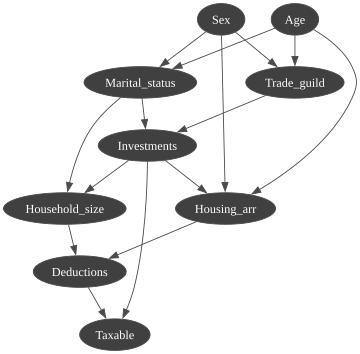

In [17]:
# The structure of the Bayesian Network is created
bn = gum.BayesNet('Catasto_1427')

# Add labelized variables
sex = bn.add(gum.LabelizedVariable("Sex", "Sex", ["1. male", "2. female"]))
marital = bn.add(gum.LabelizedVariable("Marital_status", "Marital status", ["1. single", "2. engaged", "3. married", "4. separated", "5. widowed"]))
housing = bn.add(gum.LabelizedVariable("Housing_arr", "Housing arrangement", ["1. owner", "2. tenant", "3. with_family"]))
trade = bn.add(gum.LabelizedVariable("Trade_guild", "Guild membership", ["1. yes", "2. no"]))

# Labelized variables for binned numeric variables
age = bn.add(gum.LabelizedVariable("Age", "Age group", ['1. child', '2. young_adult', '3. adult', '4. senior', '5. elder']))
hh_size = bn.add(gum.LabelizedVariable("Household_size", "Household size", ['1. 1-2', '2. 3-4', '3. 5-7', '4. 8-12', '5. 13+']))
investments = bn.add(gum.LabelizedVariable("Investments", "Investment bracket", ['1. poor', '2. lower middle', '3. upper middle', '4. wealthy', '5. affluent', '6. elite']))
deductions = bn.add(gum.LabelizedVariable("Deductions", "Deductions bracket", ['1. poor', '2. lower middle', '3. upper middle', '4. wealthy', '5. affluent', '6. elite']))
taxable = bn.add(gum.LabelizedVariable("Taxable", "Taxable bracket", ['1. poor', '2. lower middle', '3. upper middle', '4. wealthy', '5. affluent', '6. elite']))

# Add arcs based on predefined causal dependencies
bn.addArc(sex, trade)
bn.addArc(sex, marital)
bn.addArc(sex, housing)

bn.addArc(age, trade)
bn.addArc(age, marital)
bn.addArc(age, housing)

bn.addArc(marital, hh_size)
bn.addArc(marital, investments)
bn.addArc(trade, investments)
bn.addArc(investments, housing)
bn.addArc(investments, hh_size)
bn.addArc(hh_size, deductions)
bn.addArc(housing, deductions)

bn.addArc(investments, taxable) 
bn.addArc(deductions, taxable)

# Show the Bayesian Network and export to pdf
gnb.showBN(bn)
gimg.export(bn, filename="BN.pdf")

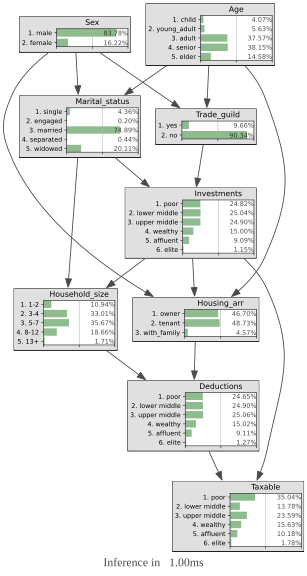

In [18]:
learner = gum.BNLearner(bayes_df)
learner.useSmoothingPrior(weight=1)      # La Place Smoothing
bn2 = learner.learnParameters(bn)        # Learn parameters on the existing BN structure
inference = gnb.showInference(bn2)

Now the question needs to be answered whether being a member of the Arti Maggiori increases taxable assets.

The number of Arti Maggiori members is 685


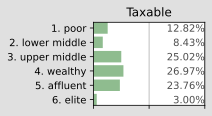

In [22]:
count = bayes_df[
    (bayes_df['Trade_guild'] == '1. yes')
].shape[0]
print("The number of Arti Maggiori members is", count)

# The lazy propagation method was used:
ie = gum.LazyPropagation(bn2)
ie.setEvidence({'Trade_guild': '1. yes'})
ie.makeInference()

# Get the posterior distribution of the Taxable variable
taxable_dist = ie.posterior(bn2.idFromName('Taxable'))
gnb.showProba(taxable_dist)

Finally, a more complex example is studied: the wealth distribution among widowed women that are house-owners.

The number of women in the Arti Maggiori is 35
The number of widowed women who own houses is 508


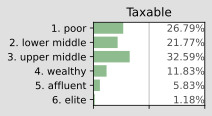

In [28]:
count = bayes_df[
    (bayes_df['Trade_guild'] == '1. yes') &
    (bayes_df['Sex'] == '2. female')
].shape[0]
print("The number of women in the Arti Maggiori is", count)

count = bayes_df[
    (bayes_df['Housing_arr'] == '1. owner') &
    (bayes_df['Sex'] == '2. female') &
    (bayes_df['Marital_status'] == '5. widowed')
].shape[0]
print("The number of widowed women who own houses is", count)

ie = gum.LazyPropagation(bn2)
ie.setEvidence({'Housing_arr': '1. owner', 'Sex': '2. female', 'Marital_status': '5. widowed'})
ie.makeInference()

# Get the posterior distribution of the Taxable variable
taxable_dist = ie.posterior(bn2.idFromName('Taxable'))
gnb.showProba(taxable_dist)